<a href="https://colab.research.google.com/github/BagusWichaksono/PCVK_Ganjil_2026/blob/main/Modul6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODUL 6 - FILTER SPASIAL
**Mata Kuliah:** Pengolahan Citra dan Visi Komputer
**Jurusan:** Teknologi Informasi - Politeknik Negeri Malang
**Repository / Notebook:** Week7.ipynb

---
### Ringkasan Tujuan Praktikum:
1. Memahami konsep dasar pemfilteran spasial dan fungsi konvolusi $2D$.
2. Membuat fungsi konvolusi $2D$ kustom tanpa menggunakan library eksternal.
3. Menerapkan berbagai kernel spasial tradisional (Sharpening, Blurring, Emboss, Line/Edge Detection).
4. Mengimplementasikan filter modern (Bilateral, Guided Filter, Feature Maps CNN, Beauty, Vintage, Cartoon, Night, & Fog Filters).
5. Menyelesaikan Tugas Analisis (Mean vs Median pada Noise Salt & Pepper), Tugas Evaluasi (Sharpening $3\times3$ vs $5\times5$), dan Tugas Kreasi (Fungsi Kartun Kustom).

## C. SEL IDENTITAS (WAJIB MENJADI SEL PERTAMA)
Sel identitas berikut digunakan sebagai standar pengujian tugas dan pelacakan parameter mahasiswa.

In [ ]:
# ===== SEL IDENTITAS JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Bagus Wichaksono Amanulloh'  # Nama Lengkap Mahasiswa
NIM  = '244107020238'              # NIM Mahasiswa
N    = int(NIM[-3:])               # 3 digit terakhir NIM

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L'   : 2 ** ((N % 3) + 1)
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
kunci = NIM + ' ' + waktu.strftime('%Y-%m-%d')

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N:', N)
for k, v in PARAM.items():
    print(f'PARAM {k:<5}: {v}')
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
print('SISTEM :', sys.version.split()[0], platform.platform())

NAMA   : Bagus Wichaksono Amanulloh
NIM    : 244107020238 | N: 238
PARAM bins : 32
PARAM clip : 2.5
PARAM tile : 4
PARAM L    : 4
WAKTU  : 2026-10-07 13:54:44 WIB
TOKEN  : 5d481fe3e6b33dba
SISTEM : 3.13.16 Linux-6.6.122+-x86_64-with-glibc2.39


## 1. Persiapan Environment dan Mount Google Drive
Mengaktifkan integrasi Google Drive, mengimpor library utama, serta mendefinisikan fungsi `show_side_by_side` untuk visualisasi komparatif.

In [ ]:
import os, glob, math
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as im
from google.colab import drive
from google.colab.patches import cv2_imshow

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Konfigurasi Path Folder Images
CONTOH = '/content/drive/MyDrive/PCVK/Images'
BASE   = '/content/drive/MyDrive/PCVK/Images/' + NIM

# Fungsi Helper Tampil Berdampingan (Sesuai Modul E)
def show_side_by_side(images, titles, figsize=(18, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:  # Grayscale
            plt.imshow(img, cmap="gray")
        else:  # Color (BGR to RGB)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(f"[{NIM}] {title}", fontsize=10)
        plt.axis("off")
    plt.show()

print("Path Konfigurasi Berhasil Dikelola:")
print("CONTOH :", CONTOH)
print("BASE   :", BASE)

Mounted at /content/drive
Path Konfigurasi Berhasil Dikelola:
CONTOH : /content/drive/MyDrive/PCVK/Images
BASE   : /content/drive/MyDrive/PCVK/Images/244107020238


---
## D. PRAKTIKUM FILTER SPASIAL (KONVOLUSI MANUAL)

### Teori Konvolusi 2D:
Proses konvolusi spasial mengalikan kernel $h(x,y)$ berukuran $K_h \times K_w$ dengan area lokal citra masukan $f(x,y)$:
$$g(x,y) = \sum_{a} \sum_{b} f(a,b) \cdot h(x-a, y-b)$$

Fungsi `convolution2d` berikut dibuat murni menggunakan pengulangan NumPy tanpa pustaka `cv.filter2D`.

In [ ]:
# D.1.c Membuat fungsi konvolusi manual
def convolution2d(image, kernel, stride=1, padding=0):
    # Penambahan Padding jika diinginkan
    if padding > 0:
        image_padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        image_padded = image.copy()

    k_h, k_w = kernel.shape
    i_h, i_w = image_padded.shape

    # Menghitung dimensi output
    out_h = (i_h - k_h) // stride + 1
    out_w = (i_w - k_w) // stride + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    # Pengulangan Konvolusi 2D
    for y in range(0, out_h):
        for x in range(0, out_w):
            sub_matrix = image_padded[y*stride : y*stride + k_h, x*stride : x*stride + k_w]
            output[y, x] = np.sum(sub_matrix * kernel)

    # Truncate / Clip nilai ke rentang piksel valid [0, 255]
    return np.clip(output, 0, 255).astype(np.uint8)

print("Fungsi convolution2d() berhasil dikonfigurasi.")

Fungsi convolution2d() berhasil dikonfigurasi.


### D.2 & D.3 Implementasi Filter Dasar dengan Manual Convolution
Menguji kernel **Sharpen**, **Emboss**, **Left Sobel Edge Detection**, **Canny/High-Pass Edge Detection**, dan **$21 \times 21$ Gaussian Blur** pada citra sampel.

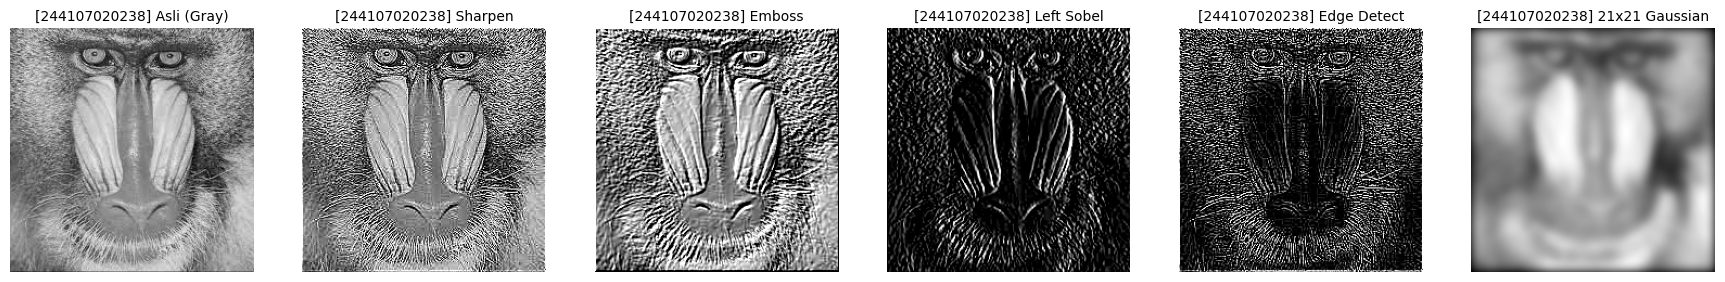

In [ ]:
# D.2.d Load Gambar (mandrill.tiff / lena.jpg)
path_img = CONTOH + '/mandrill.tiff'
if not os.path.exists(path_img):
    path_img = CONTOH + '/lena.jpg'  # Fallback jika mandrill tidak ada

img_raw = cv.imread(path_img)
if img_raw is not None:
    img_gray = cv.cvtColor(img_raw, cv.COLOR_BGR2GRAY)

    # 1. Sharpen Kernel
    kernel_sharpen = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])

    # 2. Emboss Kernel
    kernel_emboss = np.array([[-2, -1, 0],
                              [-1,  1, 1],
                              [ 0,  1, 2]])

    # 3. Left Sobel Edge Detection Kernel
    kernel_sobel_left = np.array([[1, 0, -1],
                                  [2, 0, -2],
                                  [1, 0, -1]])

    # 4. Canny / High-Pass Edge Detection Kernel
    kernel_canny_edge = np.array([[-1, -1, -1],
                                  [-1,  8, -1],
                                  [-1, -1, -1]])

    # 5. 21x21 Gaussian Blur Kernel Generator
    kernel_size = 21
    sigma = math.sqrt(kernel_size)
    gauss_1d = cv.getGaussianKernel(kernel_size, sigma)
    kernel_gaussian_21 = gauss_1d @ gauss_1d.transpose()

    # Eksekusi Konvolusi Manual
    res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
    res_emboss  = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
    res_sobel   = convolution2d(img_gray, kernel_sobel_left, stride=1, padding=1)
    res_canny   = convolution2d(img_gray, kernel_canny_edge, stride=1, padding=1)
    res_gauss   = convolution2d(img_gray, kernel_gaussian_21, stride=1, padding=10)

    # Tampilkan Hasil
    show_side_by_side(
        [img_gray, res_sharpen, res_emboss, res_sobel, res_canny, res_gauss],
        ["Asli (Gray)", "Sharpen", "Emboss", "Left Sobel", "Edge Detect", "21x21 Gaussian"],
        figsize=(22, 4)
    )
else:
    print(f"Peringatan: Berkas citra tidak ditemukan di {path_img}")

---
## E. FILTER LIBRARY DAN FILTER MODERN

### Percobaan 1: OpenCV Built-in Filters
Menerapkan `cv.GaussianBlur`, `cv.filter2D` (Sharpen), dan `cv.Canny` langsung pada citra $RGB$.

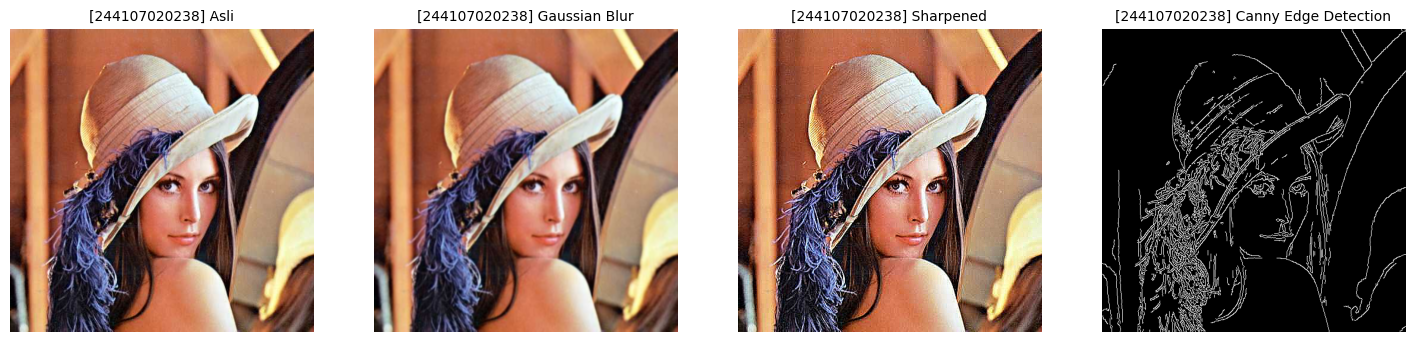

In [ ]:
# Percobaan 1: Gaussian Blur, Sharpen, & Canny dengan OpenCV
img_color = cv.imread(CONTOH + '/lena.jpg')

if img_color is not None:
    blur = cv.GaussianBlur(img_color, (7, 7), 1)
    edges = cv.Canny(cv.cvtColor(img_color, cv.COLOR_BGR2GRAY), 100, 200)

    sharpen_kernel = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])
    sharpened = cv.filter2D(img_color, -1, sharpen_kernel)

    show_side_by_side(
        [img_color, blur, sharpened, edges],
        ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"]
    )

### Percobaan 2: Filter Preservasi Tepi (Bilateral & Guided/Edge-Preserving Filter)
- **Bilateral Filter:** Menghaluskan permukaan citra berdasarkan jarak spasial sekaligus perbedaan intensitas piksel, sehingga tepi objek tetap tajam.
- **Edge Preserving Filter:** Alternatif efisien dari Guided Filter yang menghaluskan area datar tanpa mengaburkan kontur.

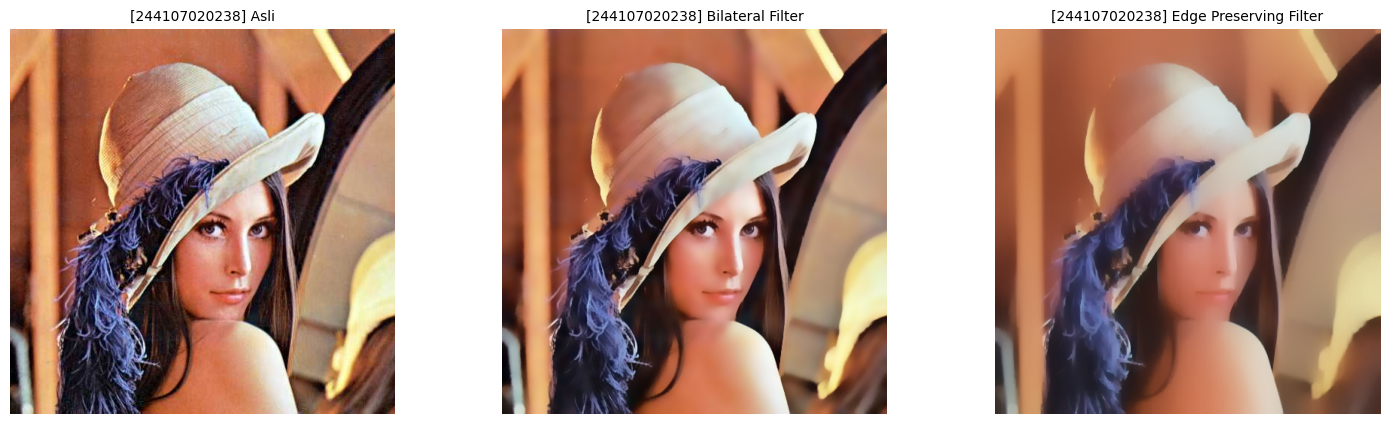

In [ ]:
if img_color is not None:
    # Bilateral Filter (edge-preserving)
    bilateral = cv.bilateralFilter(img_color, d=15, sigmaColor=100, sigmaSpace=100)

    # Edge Preserving Filter (alternatif Guided Filter)
    edge_preserve = cv.edgePreservingFilter(img_color, flags=1, sigma_s=100, sigma_r=0.9)

    show_side_by_side(
        [img_color, bilateral, edge_preserve],
        ["Asli", "Bilateral Filter", "Edge Preserving Filter"]
    )

### Percobaan 3: Filtering pada Layer Konvolusi CNN (Feature Maps)
Menggunakan PyTorch untuk melihat bagaimana *filter kernel* pada Convolutional Neural Network ($CNN$) mengekstrak fitur gambar secara otomatis.

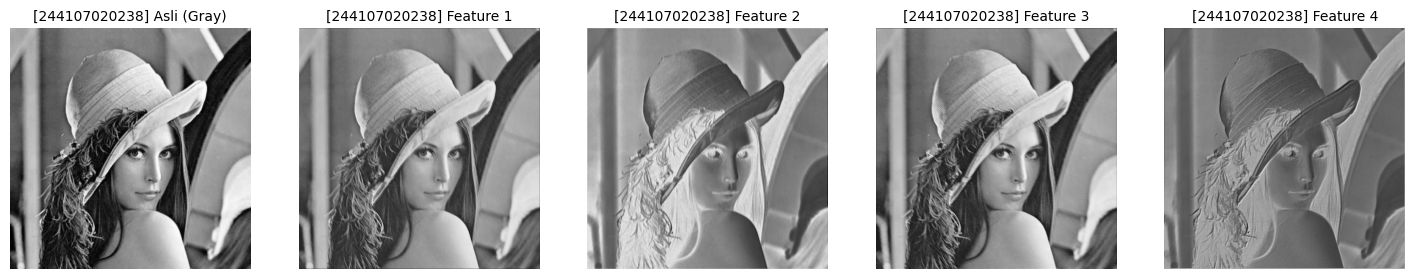

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

if img_color is not None:
    img_gray_cnn = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

    # Inisialisasi Model CNN
    model = SimpleCNN()

    # Konversi citra ke Tensor (Batch=1, Channel=1, Height, Width)
    img_tensor = torch.tensor(img_gray_cnn, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

    # Feedforward tanpa menghitung gradien
    with torch.no_grad():
        features = model(img_tensor)

    # Ekstraksi 4 Feature Maps
    feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]

    show_side_by_side(
        [img_gray_cnn] + feature_maps,
        ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))]
    )

> **Kesimpulan Percobaan 3 (Feature Maps CNN):**
> Saat kode dijalankan berulang kali, nilai bobot kernel (`self.conv1`) diinisialisasi ulang secara acak oleh PyTorch. Akibatnya, setiap *Feature Map* memperlihatkan deteksi aspek visual yang berbeda-beda (misalnya deteksi tepi vertikal, penajaman tekstur, pencerahan kontras, atau deteksi garis diagonal). Hal ini memperlihatkan bagaimana CNN mempelajari berbagai filter spasial secara independen.

### Percobaan 4 & 5: Filter Efek Visual (Beauty, Old/Vintage, & Cartoon Filter)
Kombinasi teknik filter spasial tradisional untuk menghasilkan efek sinematik dan artistik modern.

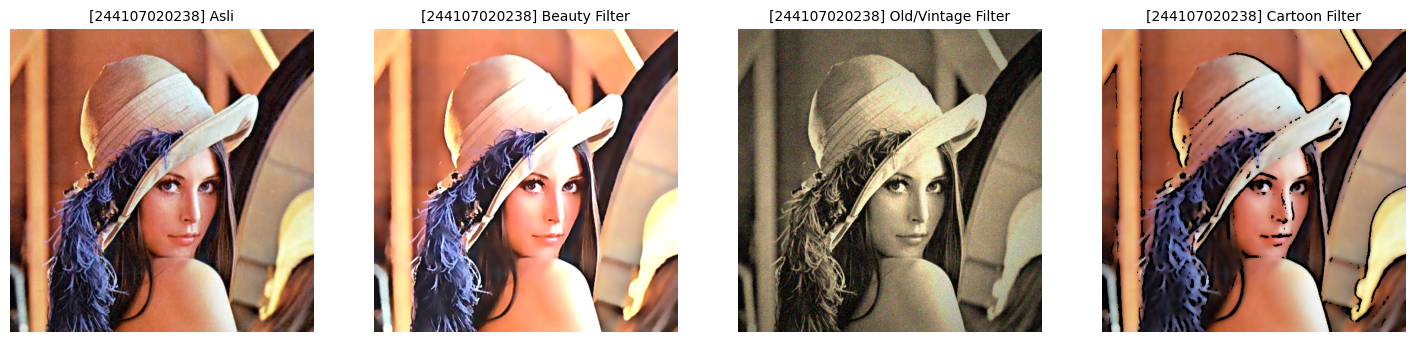

In [ ]:
if img_color is not None:
    # --- 1. Beauty Filter ---
    smooth = cv.bilateralFilter(img_color, d=15, sigmaColor=75, sigmaSpace=75)
    gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
    sharpened_b = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
    beauty = cv.convertScaleAbs(sharpened_b, alpha=1.2, beta=15)

    # --- 2. Old/Vintage Filter ---
    sepia_kernel = np.array([[0.272, 0.534, 0.131],
                             [0.349, 0.686, 0.168],
                             [0.393, 0.769, 0.189]])
    sepia = cv.transform(img_color, sepia_kernel)
    sepia = np.clip(sepia, 0, 255).astype(np.uint8)

    rows, cols = img_color.shape[:2]
    kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
    kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
    mask = (kernel_y @ kernel_x.T)
    mask = mask / mask.max()

    vignette = np.copy(sepia)
    for i in range(3):
        vignette[:, :, i] = vignette[:, :, i] * mask

    noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
    old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # --- 3. Anime / Cartoon Filter ---
    gray_c = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray_c, 7)
    edges_c = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
    color_c = cv.bilateralFilter(img_color, d=9, sigmaColor=200, sigmaSpace=200)
    cartoon = cv.bitwise_and(color_c, color_c, mask=edges_c)

    show_side_by_side(
        [img_color, beauty, old_img, cartoon],
        ["Asli", "Beauty Filter", "Old/Vintage Filter", "Cartoon Filter"]
    )

### Percobaan 6 & 7: Filter Suasana Lingkungan (Night, Morning, & Fog Filters)
Menggunakan penyesuaian kontras, bias warna (*tinting*), dan penambahan *glow layer* menggunakan konvolusi `filter2D`.

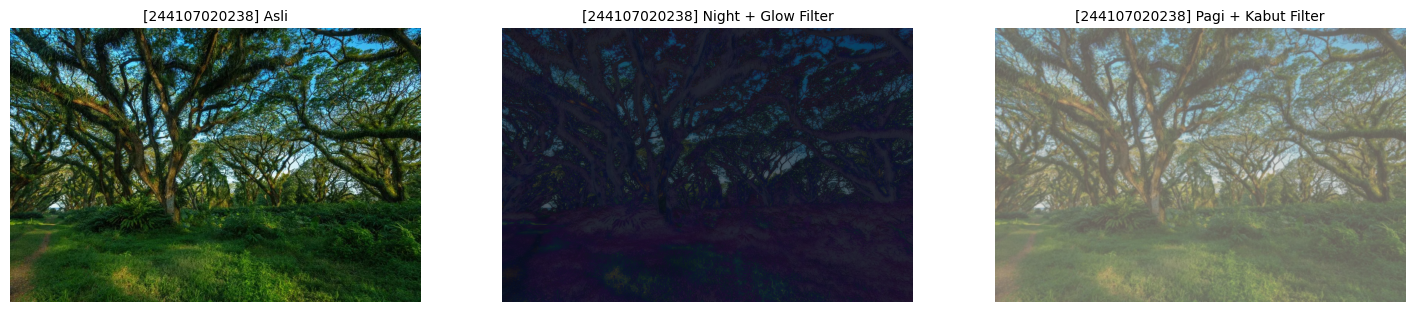

In [ ]:
# Mencoba menggunakan gambar lanskap (misal djawatan.jpg atau fallback lena.jpg)
path_bg = CONTOH + '/djawatan.jpg'
if not os.path.exists(path_bg):
    path_bg = CONTOH + '/lena.jpg'

img_env = cv.imread(path_bg)

if img_env is not None:
    # --- Filter Malam & Glow ---
    night = cv.convertScaleAbs(img_env, alpha=0.6, beta=-40)
    blue_tint = np.full_like(night, (100, 50, 20))  # Bias Biru dalam BGR
    night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

    kernel_glow = np.ones((15, 15), np.float32) / 225.0
    glow = cv.filter2D(night, -1, kernel_glow)
    night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

    # --- Filter Pagi & Kabut ---
    soft = cv.convertScaleAbs(img_env, alpha=0.9, beta=20)
    warm_tint = np.full_like(soft, (40, 70, 120))  # Bias Oranye/Hangat dalam BGR
    pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

    kernel_fog = cv.getGaussianKernel(3, 3)
    kernel_fog = kernel_fog @ kernel_fog.T
    kabut = cv.filter2D(pagi, -1, kernel_fog)
    white_layer = np.full_like(pagi, 255)
    pagi_kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

    show_side_by_side(
        [img_env, night_glow, pagi_kabut],
        ["Asli", "Night + Glow Filter", "Pagi + Kabut Filter"]
    )

---
## TUGAS PRAKTIKUM 1 (ANALISIS)
### Perbandingan Mean Filter vs. Median Filter pada Noise "Salt and Pepper"
1. Menambahkan bintik hitam-putih (*Salt and Pepper*) ke citra keabuan.
2. Menerapkan Mean Filter ($3 \times 3$) dan Median Filter ($3 \times 3$).
3. Menganalisis perbedaan visualnya.

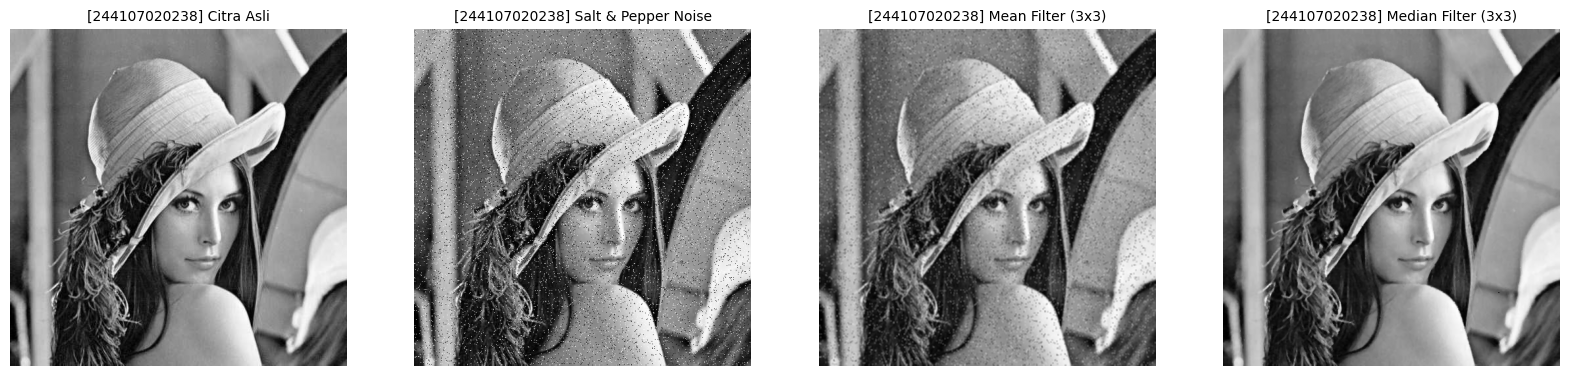

In [ ]:
def add_salt_and_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03):
    noisy = image.copy()
    # Salt (Bintik Putih)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255

    # Pepper (Bintik Hitam)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

if img_color is not None:
    gray_base = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

    # a. Tambahkan noise Salt and Pepper
    noisy_img = add_salt_and_pepper_noise(gray_base, salt_prob=0.03, pepper_prob=0.03)

    # b. Terapan Mean Filter (3x3) & Median Filter (3x3)
    mean_filtered = cv.blur(noisy_img, (3, 3))
    median_filtered = cv.medianBlur(noisy_img, 3)

    # Visualisasi
    show_side_by_side(
        [gray_base, noisy_img, mean_filtered, median_filtered],
        ["Citra Asli", "Salt & Pepper Noise", "Mean Filter (3x3)", "Median Filter (3x3)"],
        figsize=(20, 5)
    )

### ANALISIS TUGAS 1 (MEAN VS MEDIAN FILTER):
* **Mean Filter (Rata-rata):** Mengabaikan kenyataan bahwa bintik *noise* bernilai ekstrem ($0$ atau $255$). Ketika konvolusi rata-rata dihitung, nilai piksel ekstrim tersebut diikutsertakan dalam penjumlahan, sehingga piksel tetangga yang bersih justru ikut "tercemar" dan menghasilkan tampilan citra yang buram (*blurry*) dengan bintik samar yang meluas.
* **Median Filter (Nilai Tengah):** Mengurutkan nilai piksel di dalam jendela $3 \times 3$ dan mengambil nilai tengahnya. Karena bintik *noise* selalu terletak di ujung ekstrem ($0$ atau $255$), nilai ekstrem tersebut otomatis terbuang dari posisi nilai tengah (*median*). Hasilnya, *noise* Salt and Pepper terhapus secara sempurna tanpa merusak ketajaman batas tepi citra.

---
## TUGAS PRAKTIKUM 2 (EVALUASI)
### Pemilihan Ukuran Kernel Terbaik untuk Menajamkan Citra (Sharpening)
1. Membuat kernel Penajaman berukuran $3 \times 3$ dan $5 \times 5$.
2. Menerapkannya pada citra yang sedikit buram (*blurry*).
3. Evaluasi kejelasan tepi vs distorsi *noise*.

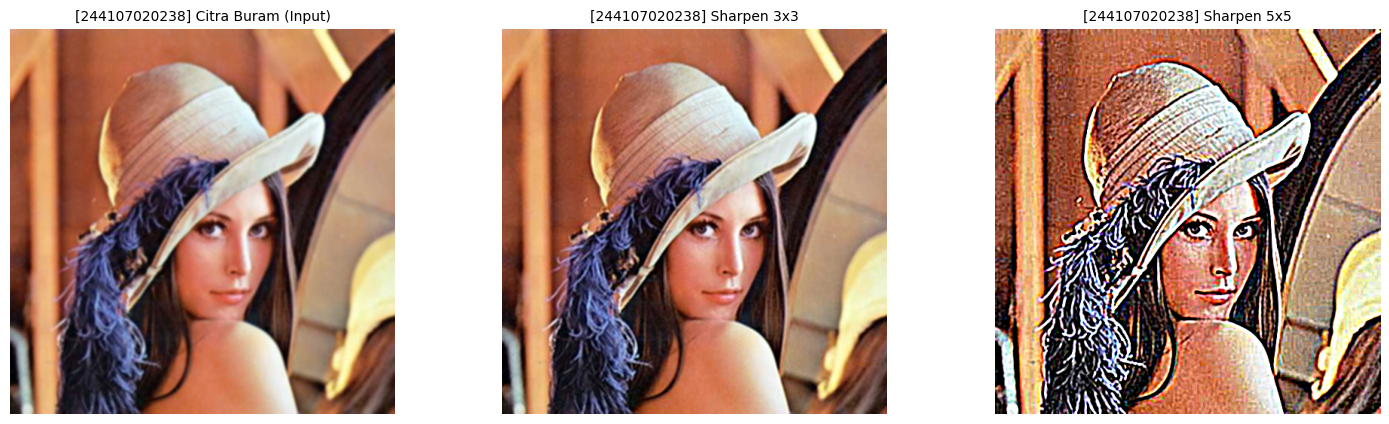

In [ ]:
if img_color is not None:
    # 1. Buat citra sedikit buram (blurry)
    blurry_img = cv.GaussianBlur(img_color, (5, 5), 1.5)

    # 2. Kernel Sharpening 3x3
    kernel_sh_3x3 = np.array([[ 0, -1,  0],
                              [-1,  5, -1],
                              [ 0, -1,  0]])

    # 3. Kernel Sharpening 5x5
    kernel_sh_5x5 = np.array([[-1, -1, -1, -1, -1],
                              [-1, -1, -1, -1, -1],
                              [-1, -1, 25, -1, -1],
                              [-1, -1, -1, -1, -1],
                              [-1, -1, -1, -1, -1]])

    # Terapan Filter
    res_sh_3x3 = cv.filter2D(blurry_img, -1, kernel_sh_3x3)
    res_sh_5x5 = cv.filter2D(blurry_img, -1, kernel_sh_5x5)

    show_side_by_side(
        [blurry_img, res_sh_3x3, res_sh_5x5],
        ["Citra Buram (Input)", "Sharpen 3x3", "Sharpen 5x5"],
        figsize=(18, 5)
    )

### EVALUASI TUGAS 2 (KERNEL SHARPENING 3x3 VS 5x5):
* **Kernel $3 \times 3$:** Meningkatkan ketajaman tepi secara natural dan proporsional. Garis kontur objek diperjelas tanpa memicu *noise artifact* yang mengganggu mata.
* **Kernel $5 \times 5$:** Terlalu agresif dalam memperkuat perbedaan intensitas lokal. Penajaman berlebih (*oversharpening*) ini memicu distorsi berupa *halo effect* (garis putih mencolok di sekitar tepi) dan memperbesar *noise* latar belakang.
* **Kesimpulan Kernel Optimal:** Kernel **$3 \times 3$** adalah pilihan paling optimal untuk penggunaan sehari-hari karena memberikan keseimbangan ideal antara kejelasan tepi dan preservasi kualitas visual.

---
## TUGAS PRAKTIKUM 3 (KREASI)
### Fungsi Kustom Filter Kartun (`kartun(image)`)
Menggabungkan:
1. **Bilateral Filter** untuk perataan area warna.
2. **Adaptive Thresholding** untuk ekstraksi garis tepi hitam.
3. **Bitwise AND** untuk mengkombinasikan warna dan garis tepi.

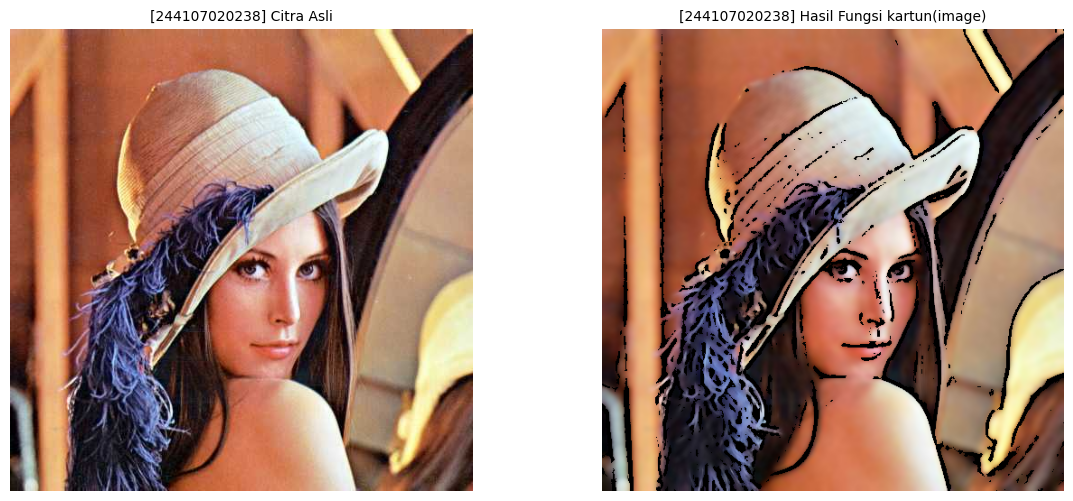

In [ ]:
# a. Membuat fungsi kustom kartun(image)
def kartun(image):
    # Step 1: Smoothing warna dengan Bilateral Filter
    color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=150, sigmaSpace=150)

    # Step 2: Deteksi garis tepi dengan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 5)
    edges = cv.adaptiveThreshold(
        gray_blur, 255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        blockSize=9, C=9
    )

    # Step 3: Penggabungan warna dan tepi menggunakan bitwise AND
    edges_color = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    cartoon_result = cv.bitwise_and(color_smooth, edges_color)

    return cartoon_result

# b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan
if img_color is not None:
    res_kartun = kartun(img_color)

    show_side_by_side(
        [img_color, res_kartun],
        ["Citra Asli", "Hasil Fungsi kartun(image)"],
        figsize=(14, 6)
    )

---
## KESIMPULAN KESELURUHAN PRAKTIKUM MODUL 6

1. **Prinsip Konvolusi Spasial:** Konvolusi 2D menggantikan nilai suatu piksel dengan kombinasi linear berbobot dari piksel-piksel tetangganya berdasarkan matriks kernel.
2. **Karakteristik Kernel Spasial:**
   * **Low-Pass Filter (Blurring):** Menghaluskan variasi intensitas dan menekan frekuensi tinggi.
   * **High-Pass Filter (Sharpening & Edge Detection):** Memperkuat perbedaan intensitas lokal untuk menonjolkan garis tepi dan detail.
3. **Pembersihan Noise:** *Median Filter* jauh lebih efektif daripada *Mean Filter* dalam menghilangkan *noise* jenis *Salt and Pepper* karena sifat non-linearnya yang mengabaikan nilai piksel ekstrem.
4. **Keunggulan Filter Modern:** *Bilateral Filter* dan *Guided Filter* mampu menghaluskan warna sekaligus menjaga ketajaman tepi, menjadi fondasi penting dalam pembuatan filter estetika modern seperti *Beauty*, *Vintage*, dan *Cartoon Filters*.